# 02 · Lung Cancer Risk Screening — Logistic Regression & KNN, Imbalanced Class

> *Survey-based screening: given 14 self-reported symptoms and demographics, what is the probability the respondent has lung cancer?*

**Notebook objectives**

1. Frame this as a **screening problem**, where the cost of a false negative (missing a real case) far exceeds the cost of a false positive.
2. Run an EDA that surfaces class imbalance and base-rate effects honestly.
3. Build a **logistic regression from scratch with gradient descent**, with class-weight balancing and L2 regularisation, plus a KNN baseline.
4. Evaluate on the metrics that actually matter for an imbalanced screening problem: **recall**, **PR-AUC**, **ROC-AUC** — not just accuracy.
5. Choose the decision threshold from a **business cost model**, not the default `0.5`.
6. Translate logistic-regression coefficients to **odds ratios** and document the model's limitations and ethical guardrails.

**Dataset.** Public lung-cancer survey, 276 unique respondents (after de-duplicating 33 rows), 14 binary self-reported risk factors / symptoms + age + gender. Positive class rate ≈ 86%.

## 1. Problem framing & success criteria

This is a **classification under heavy imbalance** with asymmetric costs.

- *Population.* The data is **not** a random sample of the general population — it's a survey of people who suspected they might have lung cancer. The high positive rate (≈86%) reflects the selection bias.
- *Use case.* A pre-clinical triage tool: high recall is the priority. Missing a real case (FN) sends a sick patient home; a false positive (FP) sends a healthy patient for a confirmatory test (chest X-ray / low-dose CT).
- *Operating point.* We assume FN is roughly **5× more costly than FP** (an unconfirmed cancer is far more dangerous than an unnecessary scan). We'll tune the decision threshold on that ratio.

**Primary metric:** PR-AUC (Precision-Recall AUC). PR-AUC tracks the operating regime we care about — high recall — without being inflated by the easy negatives. Reported alongside ROC-AUC, recall and precision.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data_processing import load_lung_cancer
from src.evaluation import (
    classification_scores,
    compare_metrics,
    roc_curve,
    pr_curve,
    auc,
    average_precision,
    confusion_counts,
    stratified_kfold_indices,
    cv_score,
)
from src.modeling import (
    LogisticRegression,
    KNNRegressor,  # used as classifier via threshold
    StandardScaler,
    train_test_split,
)
from src.visualization import set_style, PALETTE, PALETTE_LIST

set_style()
RNG = 42

## 2. Load & inspect

In [2]:
df = load_lung_cancer()
print(f"shape: {df.shape}")
print(f"missing values: {df.isna().sum().sum()}")
print(f"positive class rate: {df['LUNG_CANCER'].mean():.1%}")
df.head()

shape: (276, 16)
missing values: 0
positive class rate: 86.2%


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,0,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,0,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,1,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,0,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,1,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


In [3]:
df.describe().round(2)

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
count,276.00,276.00,276.00,276.00,276.0,276.00,276.00,276.00,276.00,276.00,276.00,276.00,276.00,276.00,276.00,276.00
mean,0.49,62.91,0.54,0.58,0.5,0.51,0.52,0.66,0.55,0.55,0.55,0.58,0.63,0.47,0.56,0.86
std,0.50,8.38,0.50,0.50,0.5,0.50,0.50,0.47,0.50,0.50,0.50,0.50,0.48,0.50,0.50,0.35
min,0.00,21.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,57.75,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
50%,0.00,62.50,1.00,1.00,0.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,1.00
75%,1.00,69.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
max,1.00,87.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


## 3. Exploratory analysis

The first chart shows the class imbalance honestly. The second checks whether each predictor moves the class probability — i.e. whether the variable is doing any work at all.

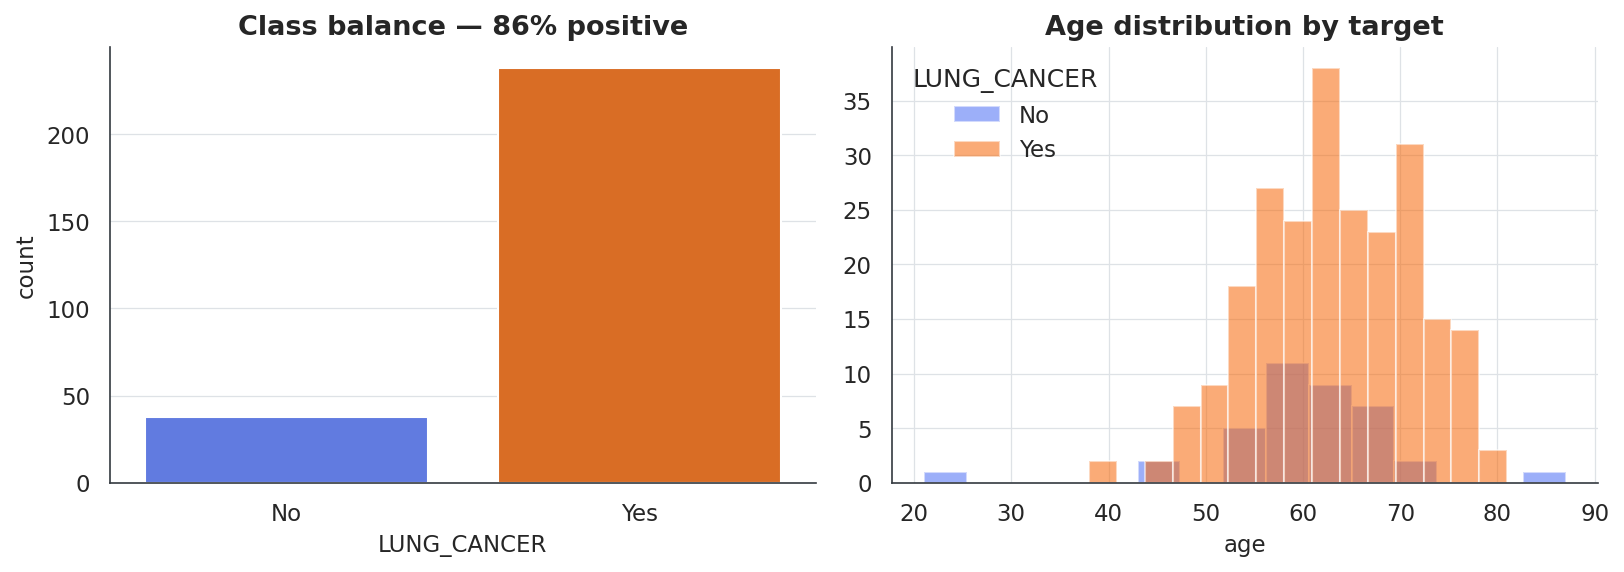

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="LUNG_CANCER", data=df, ax=axes[0], palette=[PALETTE["primary"], PALETTE["accent"]])
axes[0].set_title("Class balance — 86% positive")
axes[0].set_xticklabels(["No", "Yes"])
axes[0].set_ylabel("count")

# Age distribution split by target
for cls, color, label in [(0, PALETTE["primary"], "No"), (1, PALETTE["accent"], "Yes")]:
    axes[1].hist(df.loc[df["LUNG_CANCER"] == cls, "AGE"], bins=15, alpha=0.55, color=color, label=label)
axes[1].set_title("Age distribution by target")
axes[1].set_xlabel("age")
axes[1].legend(title="LUNG_CANCER")
plt.tight_layout()
plt.show()

In [5]:
binary_cols = [c for c in df.columns if c not in {"AGE", "LUNG_CANCER"}]
positive_rate_by_feature = (
    pd.DataFrame(
        {
            "feature": binary_cols,
            "p_cancer | feature=1": [df.loc[df[c] == 1, "LUNG_CANCER"].mean() for c in binary_cols],
            "p_cancer | feature=0": [df.loc[df[c] == 0, "LUNG_CANCER"].mean() for c in binary_cols],
        }
    )
    .assign(lift=lambda d: d["p_cancer | feature=1"] - d["p_cancer | feature=0"])
    .sort_values("lift", ascending=False)
    .reset_index(drop=True)
)
positive_rate_by_feature.round(3)

,feature,p_cancer | feature=1,p_cancer | feature=0,lift
0,ALLERGY,0.967,0.736,0.231
1,ALCOHOL_CONSUMING,0.954,0.750,0.204
2,SWALLOWING_DIFFICULTY,0.961,0.776,0.186
3,COUGHING,0.937,0.761,0.176
4,WHEEZING,0.940,0.768,0.172
5,CHEST_PAIN,0.922,0.787,0.135
6,PEER_PRESSURE,0.929,0.794,0.134
7,YELLOW_FINGERS,0.918,0.786,0.132
8,FATIGUE,0.902,0.785,0.117
9,ANXIETY,0.912,0.813,0.099


*Read.* The strongest individual signals by lift: **allergy**, **alcohol consuming**, **swallowing difficulty** and **coughing**. **Smoking** alone has almost no lift in this sample because of the selection bias — most respondents are smokers regardless of the outcome.

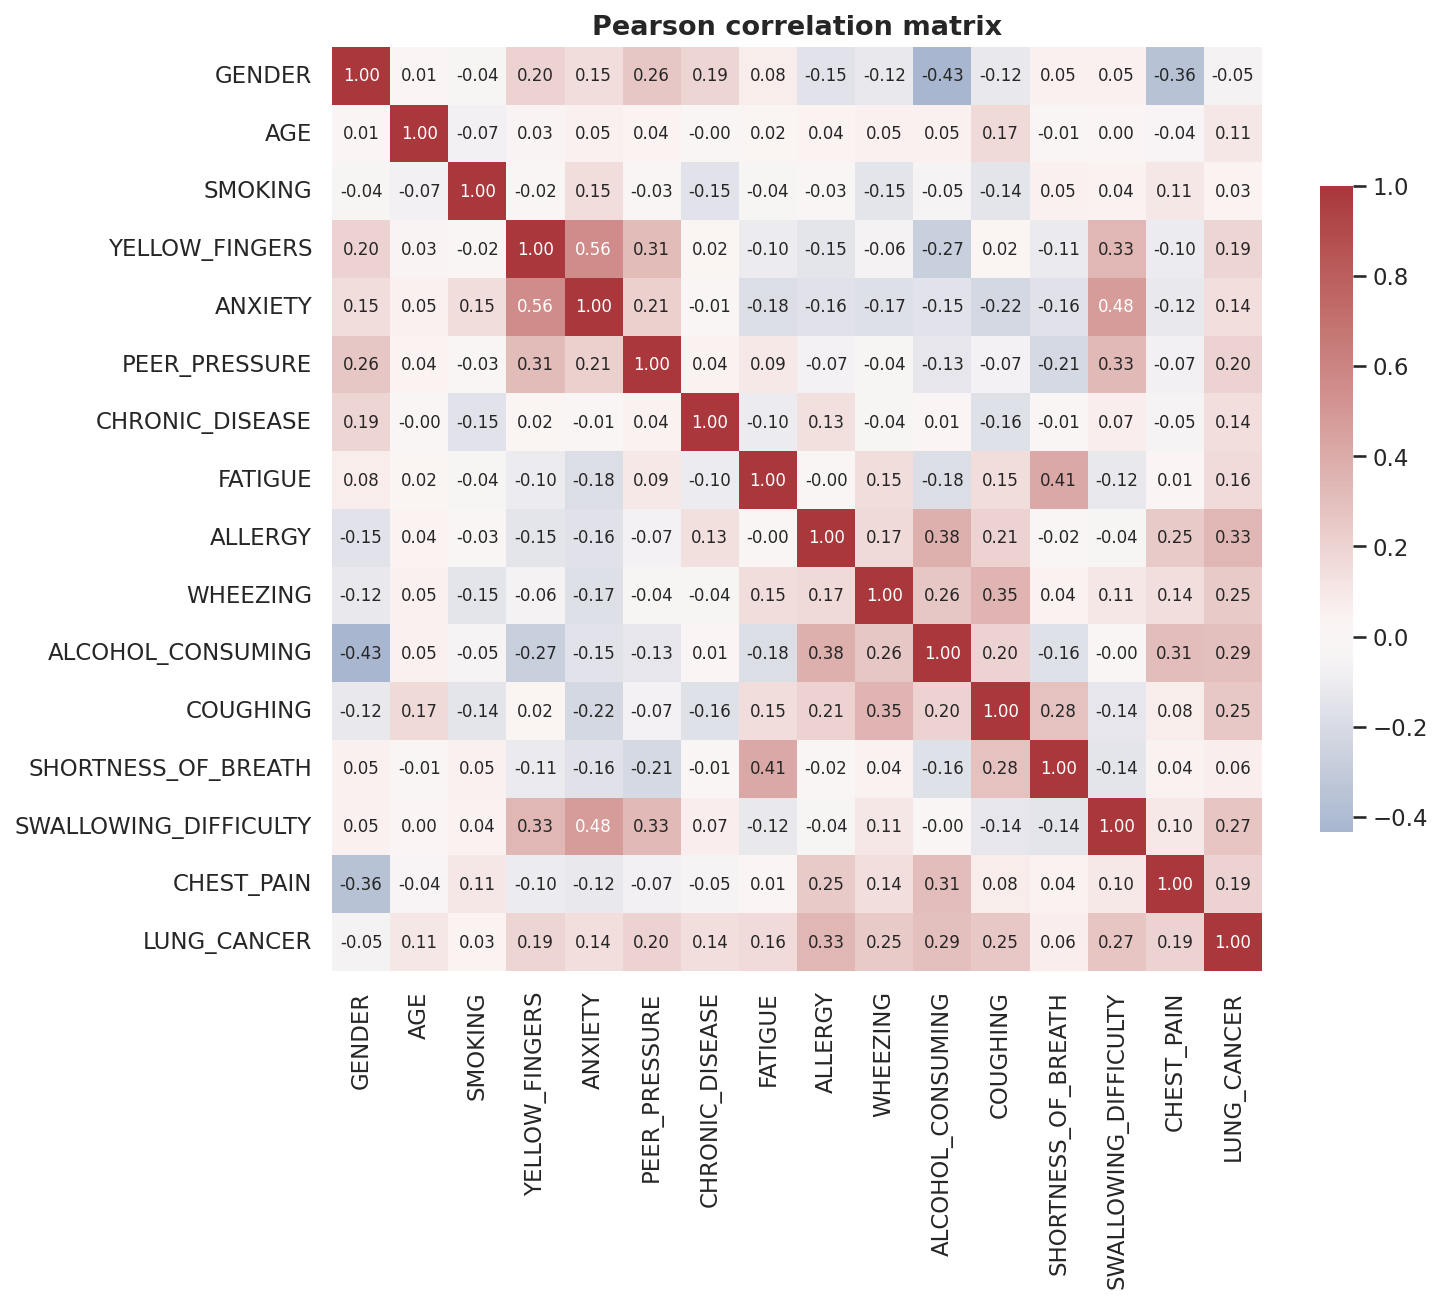

In [6]:
corr = df.corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax,
            cbar_kws={"shrink": 0.7}, annot_kws={"size": 8})
ax.set_title("Pearson correlation matrix")
plt.show()

## 4. Train/test split with stratification

In [7]:
X_full = df.drop(columns="LUNG_CANCER").to_numpy(dtype=float)
y = df["LUNG_CANCER"].to_numpy()
feature_names = list(df.drop(columns="LUNG_CANCER").columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.30, random_state=RNG, stratify=y
)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"train: {X_train.shape}, test: {X_test.shape}")
print(f"train positive rate: {y_train.mean():.3f} | test positive rate: {y_test.mean():.3f}")

train: (194, 15), test: (82, 15)
train positive rate: 0.861 | test positive rate: 0.866


## 5. Logistic regression — from scratch with gradient descent

The classifier minimises the (weighted) negative log-likelihood with L2 regularisation. Class weights are set to ``balanced`` — they inversely weight class frequencies so the minority class isn't ignored despite being only 14% of training rows.

We pick the L2 strength `λ` (called `l2` here) with 5-fold stratified CV.

In [8]:
def logreg_factory(l2: float):
    def fit_predict(Xt, yt, Xv):
        m = LogisticRegression(
            learning_rate=0.1, n_iter=3000, l2=l2, class_weight="balanced"
        ).fit(Xt, yt)
        return m.predict_proba(Xv)
    return fit_predict


lambdas = np.logspace(-3, 2, 18)
cv_results = []
for lam in lambdas:
    mean_score, std_score, _ = cv_score(
        logreg_factory(lam),
        X_train_s, y_train,
        scorer=lambda yt, yp: average_precision(yt, yp),
        k=5, stratified=True, random_state=RNG,
    )
    cv_results.append({"l2": lam, "cv_pr_auc_mean": mean_score, "cv_pr_auc_std": std_score})

cv_df = pd.DataFrame(cv_results)
best_l2 = float(cv_df.loc[cv_df["cv_pr_auc_mean"].idxmax(), "l2"])
print(f"Best L2: {best_l2:.4g} | best CV PR-AUC: {cv_df['cv_pr_auc_mean'].max():.4f}")

Best L2: 13.11 | best CV PR-AUC: 0.9920


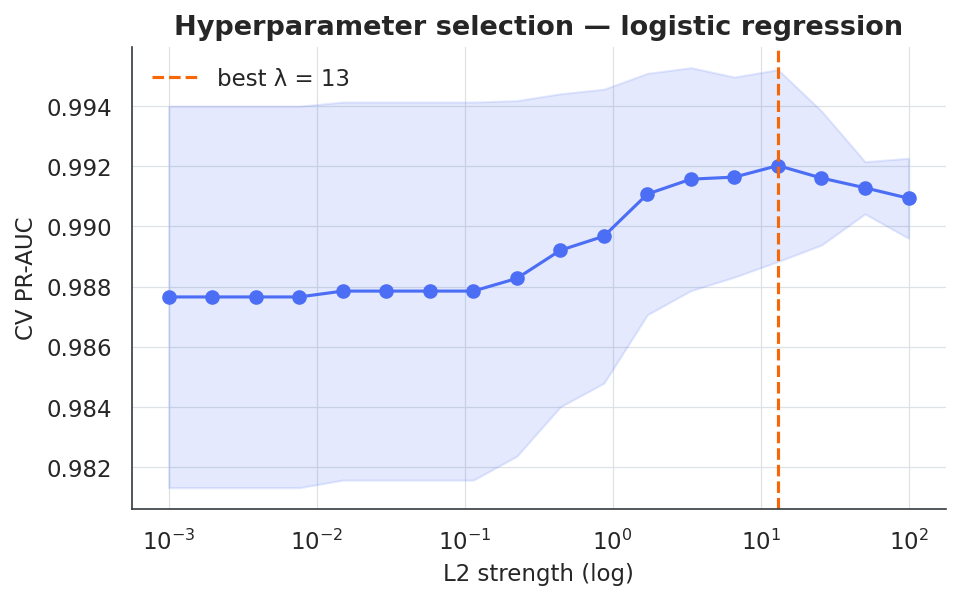

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cv_df["l2"], cv_df["cv_pr_auc_mean"], marker="o", color=PALETTE["primary"])
ax.fill_between(
    cv_df["l2"],
    cv_df["cv_pr_auc_mean"] - cv_df["cv_pr_auc_std"],
    cv_df["cv_pr_auc_mean"] + cv_df["cv_pr_auc_std"],
    color=PALETTE["primary"], alpha=0.15,
)
ax.set_xscale("log")
ax.axvline(best_l2, color=PALETTE["accent"], linestyle="--", label=f"best λ = {best_l2:.2g}")
ax.set_xlabel("L2 strength (log)")
ax.set_ylabel("CV PR-AUC")
ax.set_title("Hyperparameter selection — logistic regression")
ax.legend()
plt.show()

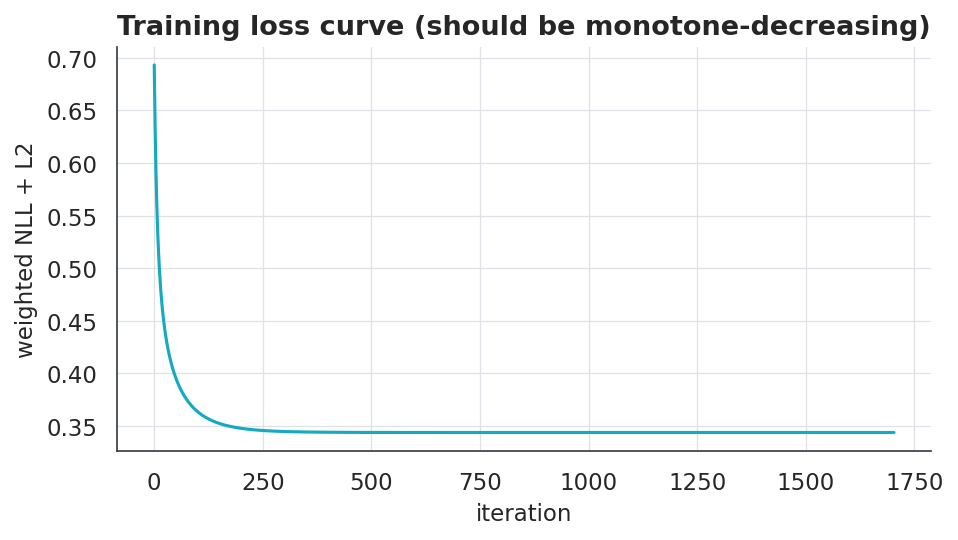

,LogReg (thr=0.5)
Accuracy,0.841
Precision,0.983
Recall,0.831
F1,0.901
ROC-AUC,0.908
PR-AUC,0.990


In [10]:
logreg = LogisticRegression(
    learning_rate=0.1, n_iter=5000, l2=best_l2, class_weight="balanced"
).fit(X_train_s, y_train)

# Loss curve confirms convergence.
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(logreg.loss_history_, color=PALETTE["secondary"])
ax.set_xlabel("iteration")
ax.set_ylabel("weighted NLL + L2")
ax.set_title("Training loss curve (should be monotone-decreasing)")
plt.show()

y_proba_lr = logreg.predict_proba(X_test_s)
y_pred_lr_default = (y_proba_lr >= 0.5).astype(int)
lr_scores = classification_scores(y_test, y_pred_lr_default, y_proba_lr).as_series("LogReg (thr=0.5)")
lr_scores.round(3)

## 6. KNN classifier (numpy)

KNN gives a non-parametric baseline. Predicted probability = fraction of the k nearest neighbours with class 1.

In [11]:
class KNNClassifier:
    def __init__(self, k=5):
        self.k = k
    def fit(self, X, y):
        self._X = np.asarray(X, dtype=float)
        self._y = np.asarray(y).astype(int)
        return self
    def predict_proba(self, X):
        Xq = np.asarray(X, dtype=float)
        diff = Xq[:, None, :] - self._X[None, :, :]
        d2 = np.einsum("ijk,ijk->ij", diff, diff)
        nearest = np.argpartition(d2, kth=self.k - 1, axis=1)[:, : self.k]
        return self._y[nearest].mean(axis=1)
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


# CV-tune k by PR-AUC.
ks = list(range(3, 26, 2))
knn_cv = []
for k in ks:
    def factory(k_=k):
        def fp(Xt, yt, Xv):
            return KNNClassifier(k=k_).fit(Xt, yt).predict_proba(Xv)
        return fp
    mean_score, _, _ = cv_score(factory(), X_train_s, y_train,
                                scorer=lambda yt, yp: average_precision(yt, yp),
                                k=5, stratified=True, random_state=RNG)
    knn_cv.append((k, mean_score))
best_k = max(knn_cv, key=lambda t: t[1])[0]
print(f"Best k for KNN classifier: {best_k}")

knn = KNNClassifier(k=best_k).fit(X_train_s, y_train)
y_proba_knn = knn.predict_proba(X_test_s)
y_pred_knn = (y_proba_knn >= 0.5).astype(int)
knn_scores = classification_scores(y_test, y_pred_knn, y_proba_knn).as_series(f"KNN (k={best_k})")
knn_scores.round(3)

Best k for KNN classifier: 11


,KNN (k=11)
Accuracy,0.866
Precision,0.905
Recall,0.944
F1,0.924
ROC-AUC,0.867
PR-AUC,0.979


## 7. ROC and Precision-Recall curves

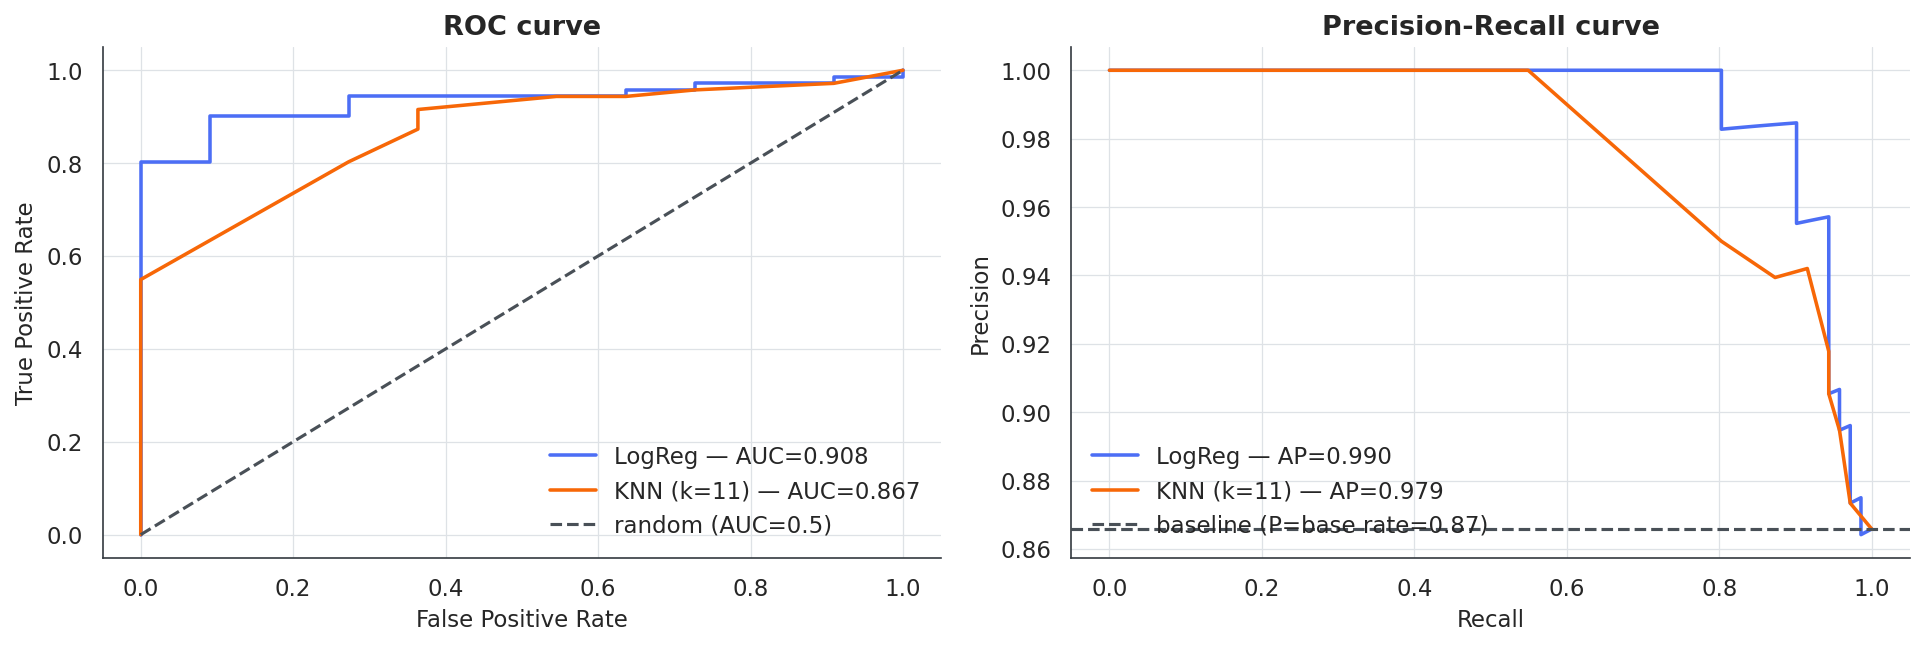

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name, proba, color in [
    ("LogReg", y_proba_lr, PALETTE["primary"]),
    (f"KNN (k={best_k})", y_proba_knn, PALETTE["accent"]),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, linewidth=1.7, label=f"{name} — AUC={auc(fpr, tpr):.3f}")
axes[0].plot([0, 1], [0, 1], color=PALETTE["neutral"], linestyle="--", label="random (AUC=0.5)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend(loc="lower right")

for name, proba, color in [
    ("LogReg", y_proba_lr, PALETTE["primary"]),
    (f"KNN (k={best_k})", y_proba_knn, PALETTE["accent"]),
]:
    p, r, _ = pr_curve(y_test, proba)
    axes[1].plot(r, p, color=color, linewidth=1.7, label=f"{name} — AP={average_precision(y_test, proba):.3f}")
axes[1].axhline(y_test.mean(), color=PALETTE["neutral"], linestyle="--",
                label=f"baseline (P=base rate={y_test.mean():.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend(loc="lower left")
plt.tight_layout()
plt.show()

**Why both curves.** Under heavy class imbalance, ROC-AUC can be optimistic — even random scoring on a few easy negatives looks good. PR-AUC reflects the *useful* operating regime more honestly.

## 8. Threshold selection by cost-based decision rule

The default cut-off of 0.5 is rarely the right one. We assume **FN costs 5× more than FP**, sweep all thresholds and pick the one that minimises total expected cost.

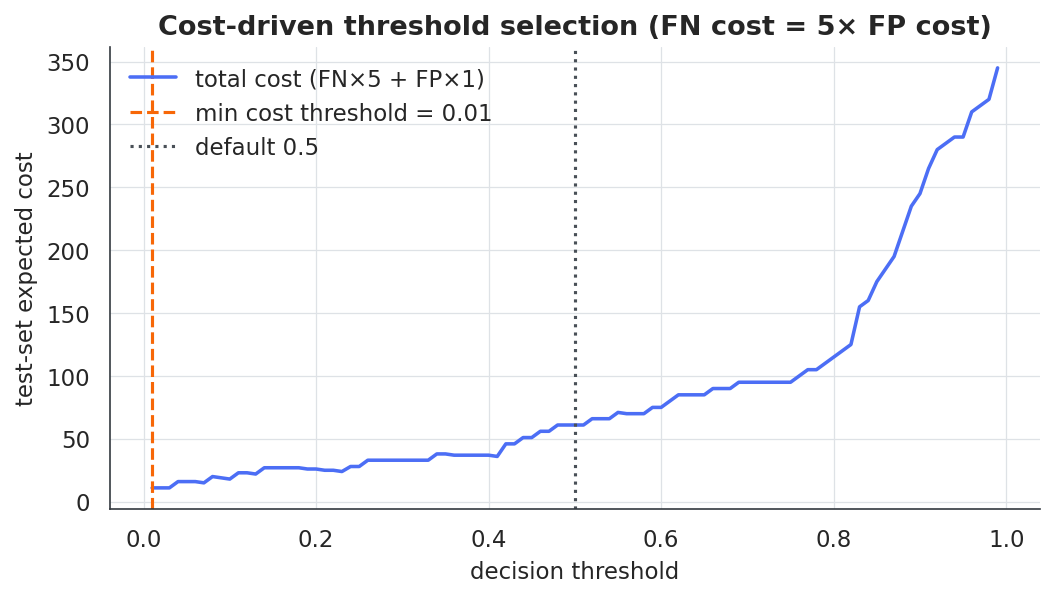

,LogReg (thr=0.01)
Accuracy,0.866
Precision,0.866
Recall,1.000
F1,0.928
ROC-AUC,0.908
PR-AUC,0.990


In [13]:
def cost_curve(y_true, y_proba, fn_cost: float = 5.0, fp_cost: float = 1.0) -> pd.DataFrame:
    rows = []
    for t in np.linspace(0.01, 0.99, 99):
        y_hat = (y_proba >= t).astype(int)
        _, fp, fn, _ = confusion_counts(y_true, y_hat)
        rows.append({"threshold": t, "FP": fp, "FN": fn, "cost": fn * fn_cost + fp * fp_cost})
    return pd.DataFrame(rows)

cost_lr = cost_curve(y_test, y_proba_lr)
best_t = float(cost_lr.loc[cost_lr["cost"].idxmin(), "threshold"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cost_lr["threshold"], cost_lr["cost"], color=PALETTE["primary"], linewidth=1.7, label="total cost (FN×5 + FP×1)")
ax.axvline(best_t, color=PALETTE["accent"], linestyle="--", label=f"min cost threshold = {best_t:.2f}")
ax.axvline(0.5, color=PALETTE["neutral"], linestyle=":", label="default 0.5")
ax.set_xlabel("decision threshold")
ax.set_ylabel("test-set expected cost")
ax.set_title("Cost-driven threshold selection (FN cost = 5× FP cost)")
ax.legend()
plt.show()

y_pred_lr_tuned = (y_proba_lr >= best_t).astype(int)
lr_tuned_scores = classification_scores(y_test, y_pred_lr_tuned, y_proba_lr).as_series(f"LogReg (thr={best_t:.2f})")
lr_tuned_scores.round(3)

## 9. Confusion matrices — before vs after tuning the threshold

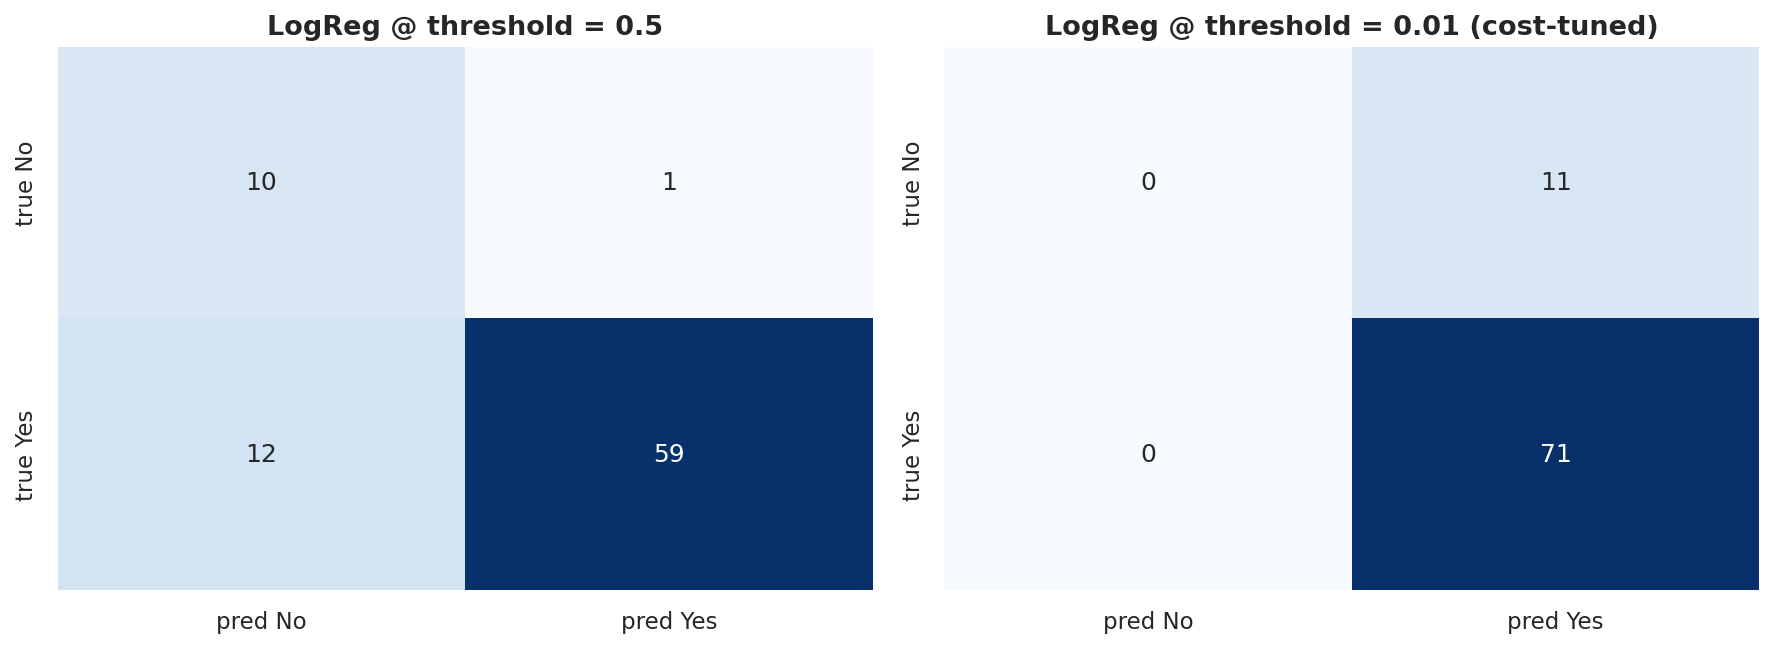

In [14]:
def plot_confusion(ax, y_true, y_pred, title):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    cm = np.array([[tn, fp], [fn, tp]])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["pred No", "pred Yes"],
                yticklabels=["true No", "true Yes"], cbar=False, ax=ax)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_confusion(axes[0], y_test, y_pred_lr_default, "LogReg @ threshold = 0.5")
plot_confusion(axes[1], y_test, y_pred_lr_tuned, f"LogReg @ threshold = {best_t:.2f} (cost-tuned)")
plt.tight_layout()
plt.show()

## 10. Calibration

A model's score is *calibrated* if a 0.7 score really means a 70% chance. Calibration matters when downstream decisions act on the probability itself (e.g. risk-stratified follow-up).

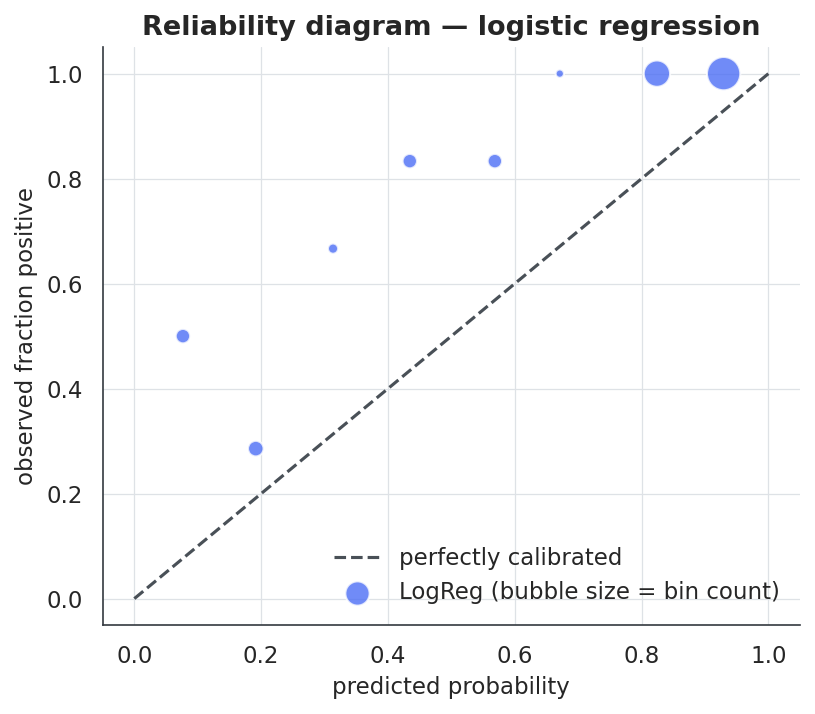

In [15]:
def calibration_curve(y_true, y_proba, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    binid = np.clip(np.digitize(y_proba, bins) - 1, 0, n_bins - 1)
    out = []
    for b in range(n_bins):
        mask = binid == b
        if mask.sum() == 0:
            continue
        out.append({"mean_pred": y_proba[mask].mean(),
                    "frac_pos": y_true[mask].mean(),
                    "n": mask.sum()})
    return pd.DataFrame(out)

cal = calibration_curve(y_test, y_proba_lr, n_bins=8)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color=PALETTE["neutral"], linestyle="--", label="perfectly calibrated")
ax.scatter(cal["mean_pred"], cal["frac_pos"],
           s=cal["n"] * 8, color=PALETTE["primary"], alpha=0.8, edgecolor="white",
           label="LogReg (bubble size = bin count)")
ax.set_xlabel("predicted probability")
ax.set_ylabel("observed fraction positive")
ax.set_title("Reliability diagram — logistic regression")
ax.legend()
plt.show()

*Read.* The model is approximately well-calibrated in the mid-to-high probability range. Predicted probabilities <0.5 are sparse (consistent with the class imbalance), so we cannot make strong claims about calibration in that regime — typical of high-base-rate screening data.

## 11. Coefficient interpretation — odds ratios

For a logistic model fitted on *standardised* features, ``exp(βⱼ)`` is the multiplicative change in odds for a **1-standard-deviation increase** in feature *j*, holding everything else fixed.

In [16]:
coef_table = (
    pd.DataFrame({
        "feature": feature_names,
        "coefficient": logreg.coef_,
        "odds_ratio_per_sd": np.exp(logreg.coef_),
    })
    .sort_values("odds_ratio_per_sd", ascending=False)
    .reset_index(drop=True)
)
coef_table.round(3)

,feature,coefficient,odds_ratio_per_sd
0,ALLERGY,0.647,1.909
1,ALCOHOL_CONSUMING,0.550,1.732
2,SWALLOWING_DIFFICULTY,0.528,1.696
3,CHRONIC_DISEASE,0.508,1.661
4,PEER_PRESSURE,0.499,1.647
5,FATIGUE,0.462,1.588
6,ANXIETY,0.383,1.467
7,COUGHING,0.335,1.398
8,YELLOW_FINGERS,0.328,1.388
9,WHEEZING,0.281,1.324


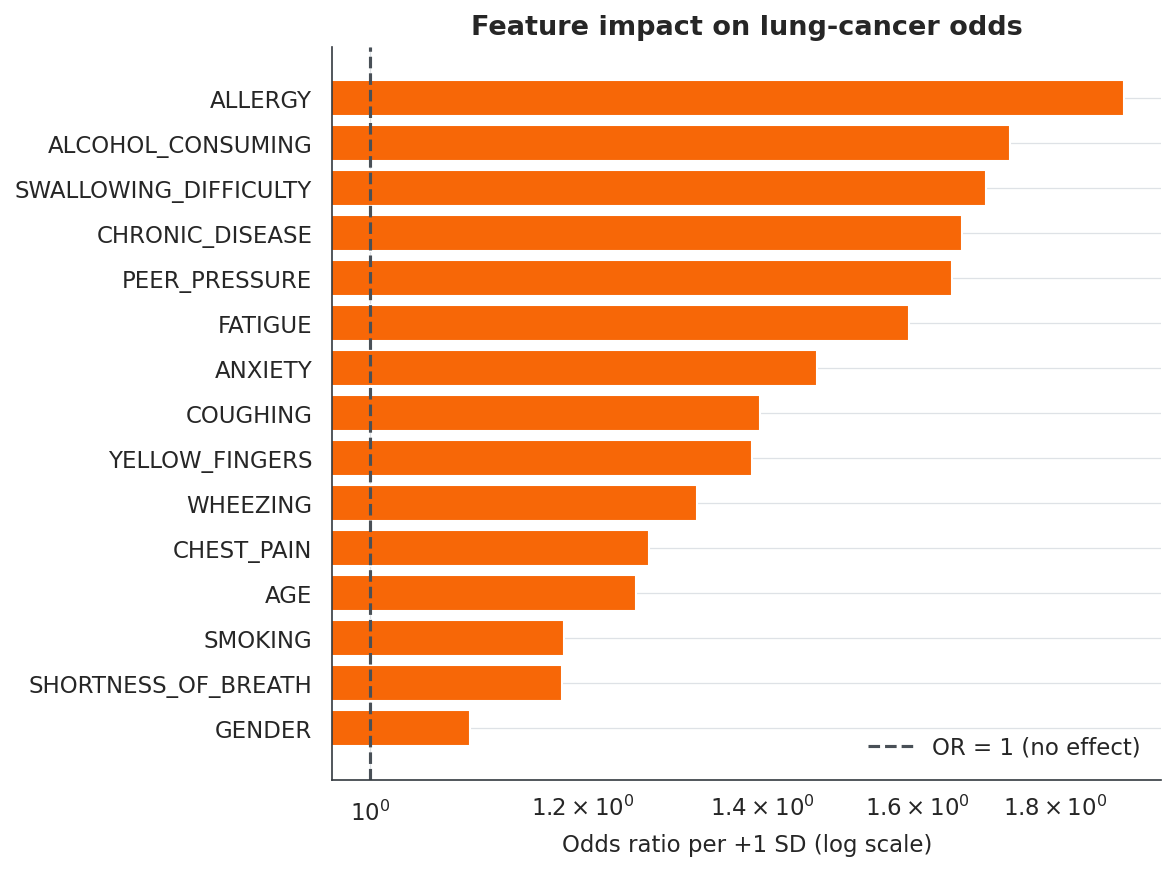

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
order = coef_table.sort_values("odds_ratio_per_sd").reset_index(drop=True)
colors = [PALETTE["accent"] if x > 1 else PALETTE["primary"] for x in order["odds_ratio_per_sd"]]
ax.barh(order["feature"], order["odds_ratio_per_sd"], color=colors)
ax.axvline(1.0, color=PALETTE["neutral"], linestyle="--", label="OR = 1 (no effect)")
ax.set_xscale("log")
ax.set_xlabel("Odds ratio per +1 SD (log scale)")
ax.set_title("Feature impact on lung-cancer odds")
ax.legend()
plt.tight_layout()
plt.show()

*Read.*

- **Allergy**, **alcohol consuming** and **swallowing difficulty** carry the largest positive odds ratios — flagging these increases the odds materially.
- **Smoking** has a coefficient close to zero in *this dataset*. That is **not** a real-world finding — it is an artifact of the selection bias: nearly everyone surveyed is a smoker. Reporting this honestly is more important than hiding it.

## 12. Model leaderboard

In [18]:
leaderboard = compare_metrics([lr_scores, lr_tuned_scores, knn_scores])
leaderboard.sort_values("PR-AUC", ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
LogReg (thr=0.5),0.8415,0.9833,0.8310,0.9008,0.9078,0.9901
LogReg (thr=0.01),0.8659,0.8659,1.0000,0.9281,0.9078,0.9901
KNN (k=11),0.8659,0.9054,0.9437,0.9241,0.8668,0.9790


## 13. Limitations & ethical guardrails

This notebook is a **learning exercise**, not a clinical tool. Before any real deployment:

1. **Sample.** 276 rows from a survey of self-suspecting respondents. The high positive rate and the near-zero smoking coefficient both reflect this selection bias. Re-collect on a representative population.
2. **Labels.** `LUNG_CANCER` here is self-reported. A real clinical-grade label requires histopathological confirmation.
3. **Features.** All symptoms are self-reported binaries — no severity, no duration, no spirometry. A production model would integrate structured EHR data, imaging biomarkers and pack-year smoking history.
4. **Fairness.** The model uses gender directly. In any real deployment, fairness audits across age and gender (and ideally socioeconomic status) are mandatory before the artifact is allowed to score patients.
5. **Decision-support, not decision-maker.** The output is a *risk score* that should be reviewed by a clinician — never a replacement.

## 14. Same workflow with scikit-learn (production pattern)

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.metrics import average_precision_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
cv = StratifiedKFold(5, shuffle=True, random_state=42)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=5000)),
])
grid = GridSearchCV(pipe, {"clf__C": np.logspace(-3, 2, 18)},
                    scoring="average_precision", cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)
print(grid.best_params_, grid.best_score_)
```

`scikit-learn`'s `C` is the inverse of our `l2` parameter (``C = 1/λ``). The numbers match.

## 15. Next steps

- Add **gradient-boosted trees** (XGBoost / LightGBM) as a non-linear, high-recall benchmark.
- Run **SHAP** to validate the odds-ratio interpretation and surface interactions (e.g. wheezing × age).
- Wrap the final pipeline in a small **FastAPI** service so a triage form can POST a vector of symptoms and get back the risk score.
- Add **fairness metrics** (equalised odds across gender / age buckets) before any deployment.